In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

proteins = ['YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY']
# proteins = ['chignolin']
estimator = STiMetaD(minSampleSize=5)
samples = {}
for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]


    results = []

    for i in range(4000, 4100):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

        df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")

        above_threshold = df[df["rmsd"] > 0.15]
        if above_threshold.empty:
            print(f"No frame above threshold in run {index_str}")
            continue

        first_hit = above_threshold.iloc[0]
        first_hit["run"] = index_str
        time = first_hit["time"] 
        acc = first_hit["metad.acc"]
        predicted = time * acc
        first_hit["predicted"] = predicted
        
        results.append(first_hit)

    results_df = pd.DataFrame(results)

    results_df.sort_values(by="time", inplace=True)
    samples[protein] = results_df


    # print(f"{protein} - MFPT (μs): {}")

mfpt = [estimator.estimateMFPT(samples=np.array(samples[protein]['predicted'])) / 1e6 for protein in proteins]



No frame above threshold in run 4000
No frame above threshold in run 4001
No frame above threshold in run 4002
No frame above threshold in run 4003
No frame above threshold in run 4004
No frame above threshold in run 4008
No frame above threshold in run 4010
No frame above threshold in run 4013
No frame above threshold in run 4014
No frame above threshold in run 4016
No frame above threshold in run 4018
No frame above threshold in run 4019
No frame above threshold in run 4022
No frame above threshold in run 4024
No frame above threshold in run 4029
No frame above threshold in run 4031
No frame above threshold in run 4035
No frame above threshold in run 4039
No frame above threshold in run 4045
No frame above threshold in run 4051
No frame above threshold in run 4052
No frame above threshold in run 4053
No frame above threshold in run 4055
No frame above threshold in run 4057
No frame above threshold in run 4058
No frame above threshold in run 4059
No frame above threshold in run 4060
N

KeyboardInterrupt: 

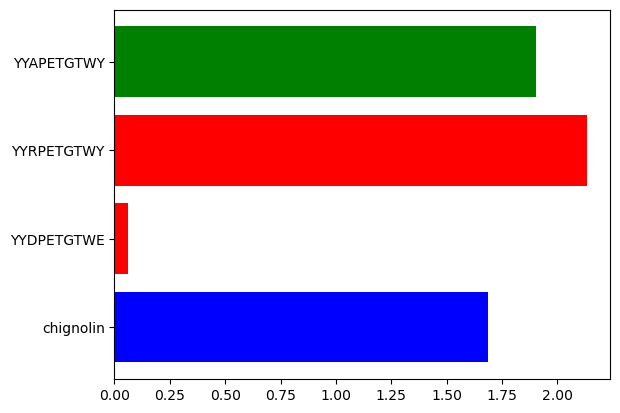

In [28]:
plt.barh(proteins, mfpt, color=['blue', 'red', 'red', 'green'])
plt.show()

/rg/mendels_prj/alexander.z/protein-toolkit/src/STiMetaD.py:66: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / data.loc[data.R2 == data.R2.max()].prediction)


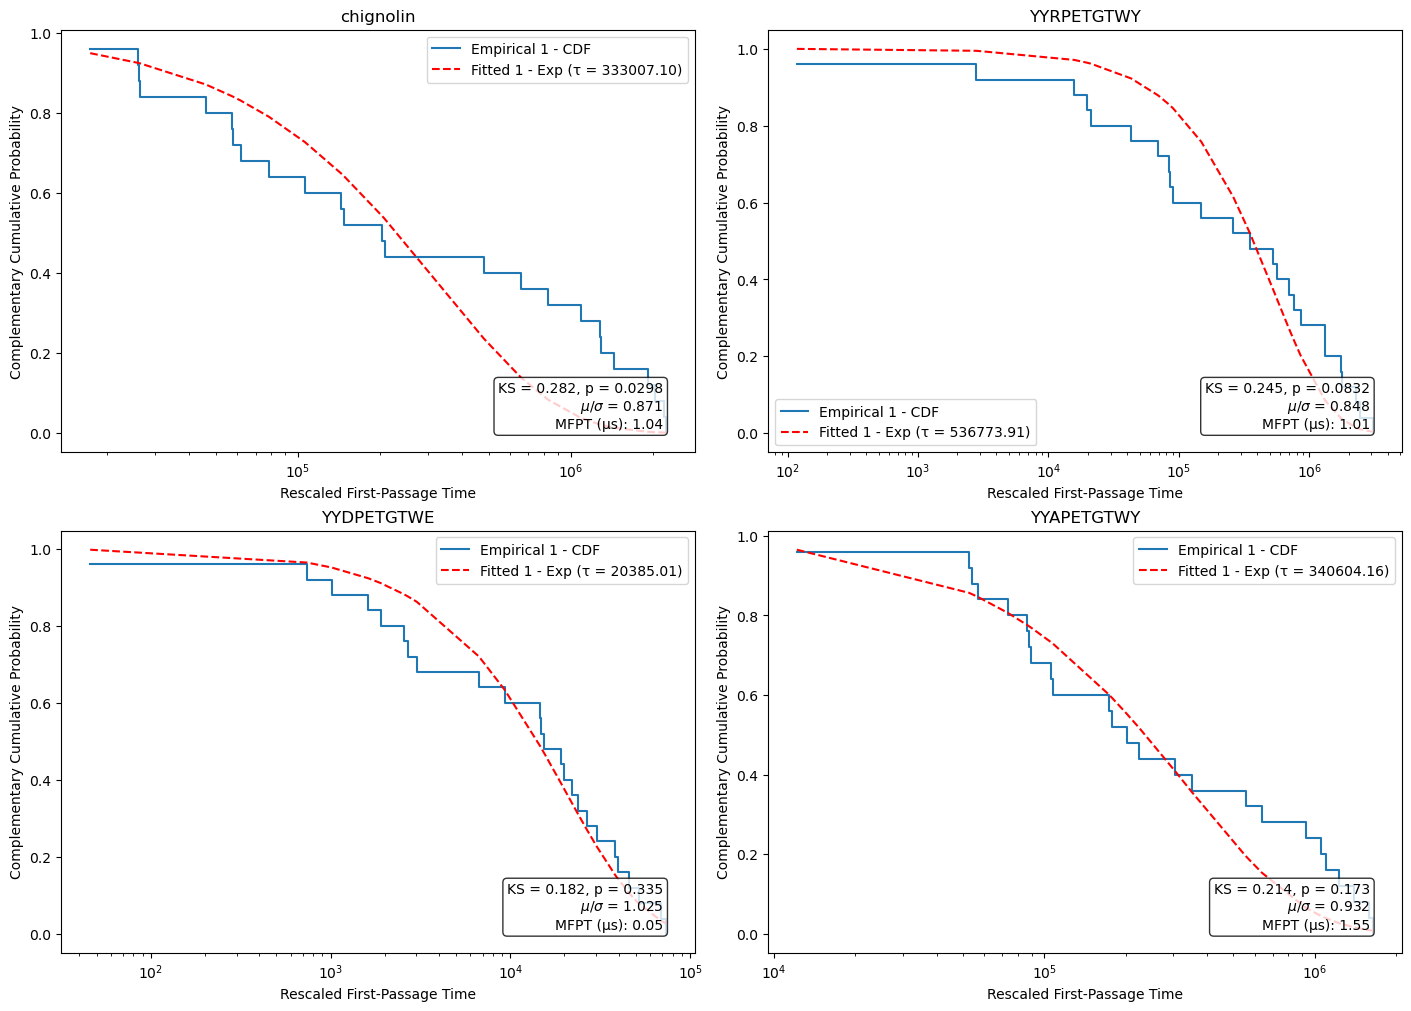

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, kstest
from scipy import optimize

def cumulative_exp(x, tau):
    return 1 - np.exp(-x / tau)

n_cols = 2
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), constrained_layout=True)

for idx, protein in enumerate(proteins):
    row, col = divmod(idx, n_cols)
    ax = axes[col][row]

    ax.set_xscale('log')
    samples_sorted = samples[protein].sort_values(by="predicted")
    predicted = np.array(samples_sorted["predicted"])[:25]

    n = len(predicted)
    CDF = np.arange(1, n + 1) / n 

    tau_fit = optimize.curve_fit(cumulative_exp, predicted, CDF, p0=(np.mean(predicted)))[0][0]
    fitted_CDF = cumulative_exp(predicted, tau_fit)

    ax.step(predicted, 1 - CDF, label="Empirical 1 - CDF", where='post')
    ax.plot(predicted, 1 - fitted_CDF, 'r--', label=f"Fitted 1 - Exp (τ = {tau_fit:.2f})")

    ax.set_title(protein)
    ax.set_xlabel('Rescaled First-Passage Time')
    ax.set_ylabel('Complementary Cumulative Probability')
    ax.legend()

    mu = np.mean(predicted)
    sigma = np.std(predicted)
    mean_std_ratio = mu / sigma

    ks_stat, p_value = kstest(predicted, 'expon', args=(0, tau_fit))

    mfpt_us = estimator.estimateMFPT(samples= np.array(samples_sorted["predicted"])) / 1e6

    stats_text = (
        f"KS = {ks_stat:.3f}, p = {p_value:.3g}\n"
        f"$\\mu/\\sigma$ = {mean_std_ratio:.3f}\n"
        f"MFPT (μs): {mfpt_us:.2f}"
    )
    ax.text(0.95, 0.05, stats_text,
            transform=ax.transAxes,
            fontsize=10, va='bottom', ha='right',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.show()


In [24]:
import numpy as np



median = np.median(samples)
median_meanln2_ratio = median / (mu * np.log(2))
print(f"median / (μ ln 2) = {median_meanln2_ratio:.3f} (should be ≈ 1)")


from scipy.stats import expon, kstest

# Fit exponential (assumes transitions start at t=0)
loc, tau = expon.fit(samples, floc=0)



TypeError: unsupported operand type(s) for /: 'dict' and 'int'